
## Sesión 4.Introducción al Aprendizaje por Refuerzo en entornos continuos discretizados. 
#### Inteligencia Artificial 2024 / 25
##### Belén Díaz Agudo 

En la parte 1 hemos trabado con dominios discretos. 
El dominio Cart-Pole es un ejemplo de dominio continuo en el que  tenemos un poste que está unido por una articulación no accionada a un carro, que se mueve a lo largo de una pista sin fricción. El sistema se controla aplicando una fuerza de +1 o -1 al carro. El péndulo comienza en posición vertical y el objetivo es evitar que se caiga. Se proporciona una recompensa de +1 por cada paso de tiempo que el poste permanece en posición vertical. El episodio termina cuando el poste está a más de 15 grados de la vertical o el carro se mueve más de 2.4 unidades desde el centro.



https://gymnasium.farama.org/environments/classic_control/cart_pole/


In [3]:
#Sergio Martínez Olivera y Daniel Roldán Serrano
import gymnasium as gym

In [4]:
# Generamos el entorno CartPole v1 y realizamos acciones aleatorias 
env = gym.make('CartPole-v1', render_mode="human")
for i_episode in range(20):
    observation,_ = env.reset()
    for t in range(10):
        env.render()
        print(observation)
        action = env.action_space.sample()
        observation, reward, done, info,_ = env.step(action)
        if done:
            print("Episode finished after {} timesteps".format(t+1))
            break
env.close()

[ 0.0116531  -0.04354979 -0.04276283 -0.00668352]
[ 0.0107821   0.15215853 -0.04289651 -0.31254604]
[ 0.01382527 -0.0423269  -0.04914743 -0.03369399]
[ 0.01297874 -0.23671086 -0.04982131  0.24308635]
[ 0.00824452 -0.43108708 -0.04495958  0.5196475 ]
[-0.00037722 -0.23536198 -0.03456663  0.21314286]
[-0.00508446 -0.03976332 -0.03030377 -0.09024043]
[-0.00587973 -0.2344381  -0.03210858  0.19272971]
[-0.01056849 -0.42908636 -0.02825399  0.47511333]
[-0.01915022 -0.6237982  -0.01875172  0.7587589 ]
[-0.0022909  -0.01445326  0.02218026  0.02929352]
[-0.00257996 -0.20988615  0.02276613  0.32889122]
[-0.00677768 -0.40532467  0.02934395  0.6286657 ]
[-0.01488418 -0.21062426  0.04191726  0.3453667 ]
[-0.01909666 -0.01612288  0.0488246   0.06619096]
[-0.01941912 -0.2119096   0.05014842  0.3738698 ]
[-0.02365731 -0.4077067   0.05762581  0.6819337 ]
[-0.03181145 -0.2134304   0.07126449  0.40793556]
[-0.03608005 -0.40948665  0.0794232   0.7222075 ]
[-0.04426979 -0.60561216  0.09386735  1.0387943 ]


#### Documentación del problema
    Description:
        A pole is attached by an un-actuated joint to a cart, which moves along
        a frictionless track. The pendulum starts upright, and the goal is to
        prevent it from falling over by increasing and reducing the cart's
        velocity.
    Source:
        This environment corresponds to the version of the cart-pole problem
        described by Barto, Sutton, and Anderson
    Observation:
        Type: Box(4)
        Num     Observation               Min                     Max
        0       Cart Position             -4.8                    4.8
        1       Cart Velocity             -Inf                    Inf
        2       Pole Angle                -0.418 rad (-24 deg)    0.418 rad (24 deg)
        3       Pole Angular Velocity     -Inf                    Inf
    Actions:
        Type: Discrete(2)
        Num   Action
        0     Push cart to the left
        1     Push cart to the right
        Note: The amount the velocity that is reduced or increased is not
        fixed; it depends on the angle the pole is pointing. This is because
        the center of gravity of the pole increases the amount of energy needed
        to move the cart underneath it
    Reward:
        Reward is 1 for every step taken, including the termination step
    Starting State:
        All observations are assigned a uniform random value in [-0.05..0.05]
    Episode Termination:
        Pole Angle is more than 12 degrees.
        Cart Position is more than 2.4 (center of the cart reaches the edge of
        the display).
        Episode length is greater than 200.
        Solved Requirements:
        Considered solved when the average return is greater than or equal to
        195.0 over 100 consecutive trials.


# Entender el entorno
https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

In [5]:
env = gym.make('CartPole-v1')
env.action_space


Discrete(2)

In [6]:
env.observation_space

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

In [7]:
env.action_space.sample()

1

In [8]:
env.observation_space.sample()

array([ 3.5823832 , -0.5497228 ,  0.05267251,  0.7355783 ], dtype=float32)

In [9]:
import numpy as np
import gymnasium
import random
from IPython.display import clear_output

class QLearnAgent():
    def __init__(self, number_bins = (20,20,20,20)):
        bounds = (4.8, 4, .418, 4)
        self.bins = [ np.linspace(-1*bound, bound, numBins) for (bound, numBins) in zip(bounds, number_bins)]
        
        self.q_table = np.random.uniform(low=-2, high=0, size=[*number_bins, 2])
        self.env = gym.make('CartPole-v1')
        
    def discretize(self, obs):
        return tuple(np.digitize(obs_data, bins)-1 for (obs_data, bins) in zip(obs, self.bins))
    
    def fill_table(self, alpha = 0.75, gamma = 0.75, epsilon = 1, total_episodes=10000, info_control_time=100):
        info = {"step": [], "avg": []}
        
        env = self.env
        reduce_epsilon_start = 1
        reduce_epsilon_end = total_episodes // 2
        reduce_epsilon_value = epsilon / (reduce_epsilon_end - reduce_epsilon_start)
        
        previous = []
        q_table = self.q_table
        for i in range(1, total_episodes):            
            done = False
            discrete_state = self.discretize(env.reset()[0])
            steps = 0
            while not done:
                steps += 1
                if random.random() < epsilon:
                    action = env.action_space.sample() # Explore action space
                else:
                    action = np.argmax(q_table[discrete_state])

                next_state, reward, done, _, _ = env.step(action) 
                next_discrete_state = self.discretize(next_state)
                
                next_max = np.max(q_table[next_discrete_state])
                old_value = q_table[discrete_state + (action,)]
            
                if done and steps < 200:
                    reward = -375

                new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
                q_table[discrete_state + (action,)] = new_value
                discrete_state = next_discrete_state
                
            previous.append(steps)
                
            if i % info_control_time == 0:
                clear_output(wait=True)
                print(f"Episode: {i}")
                latest = previous [-info_control_time:]
                info["step"].append(i)
                info["avg"].append(sum(latest)/len(latest))
                
            if reduce_epsilon_end >= i >= reduce_epsilon_start:
                epsilon -= reduce_epsilon_value
        
        return info


In [10]:
q = QLearnAgent()
info = q.fill_table(alpha = 0.75, gamma = 0.75, epsilon = 1, total_episodes = 1500)


Episode: 1400


Text(0.5, 1.0, 'Comportamiento del agente\n($\\alpha = 0.75$, $\\gamma=0.75$, $\\epsilon=1$)')

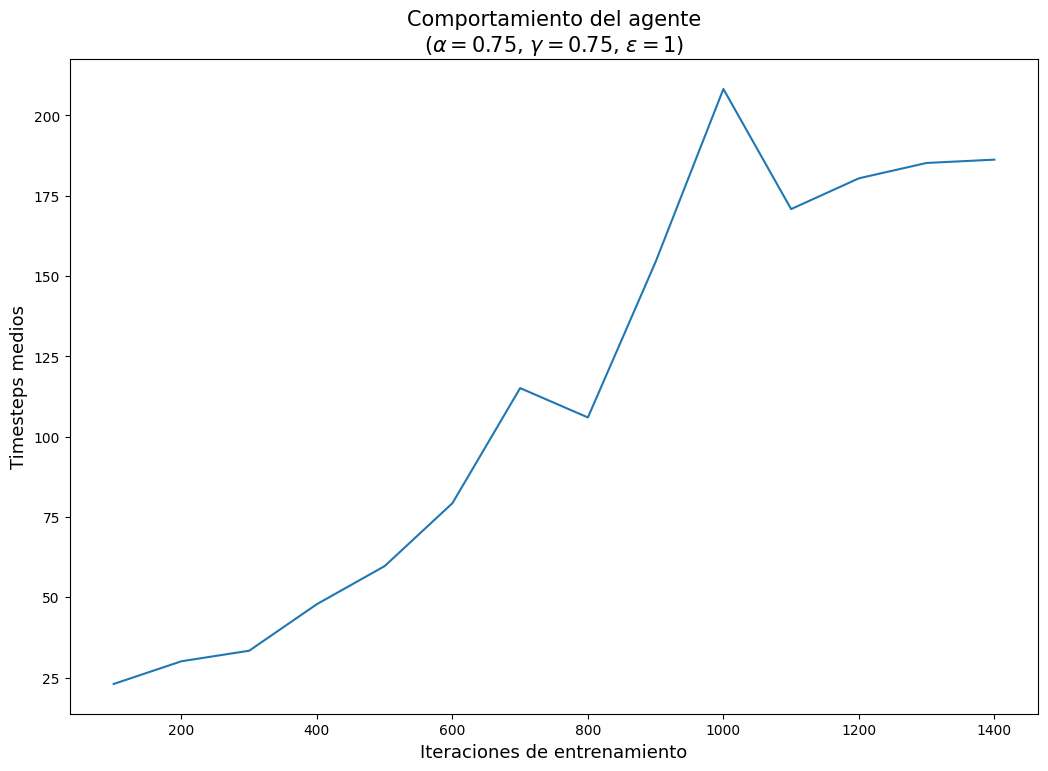

In [11]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

fig, ax = plt.subplots(1)
fig.set_size_inches(12.5, 8.5, forward=True)
ax.plot(info["step"], info["avg"])
ax.set_xlabel("Iteraciones de entrenamiento", size = 13)
ax.set_ylabel("Timesteps medios", size = 13)
ax.set_title(r"Comportamiento del agente" + "\n"
             r"($\alpha = 0.75$, $\gamma=0.75$, $\epsilon=1$)", size=15)

In [12]:
import math
import numpy as np
alpha_distinct = 5
epsilon_distinct = 5
gamma_distinct = 5

alphas, epsilons, gammas = np.linspace(0, 1, alpha_distinct), np.linspace(0,1,epsilon_distinct),\
    np.linspace(0,1, gamma_distinct)


total_episodes = 1001
info_control_time = 100
data_points = math.ceil(total_episodes/info_control_time)
metric = np.zeros([alpha_distinct, epsilon_distinct, gamma_distinct, data_points])
for alpha in alphas:
    alpha_i = np.digitize(alpha, alphas)-1
    for epsilon in epsilons:
        epsilon_i = np.digitize(epsilon, epsilons)-1
        for gamma in gammas:
            gamma_i = np.digitize(gamma, gammas)-1

            q = QLearnAgent()
            info = q.fill_table(alpha=alpha, epsilon=epsilon, gamma=gamma,
                                total_episodes = total_episodes, info_control_time = info_control_time)
            for (step, avg) in zip(info["step"], info["avg"]):
                metric[alpha_i, epsilon_i, gamma_i, step//info_control_time] = avg
            


Episode: 900


KeyboardInterrupt: 

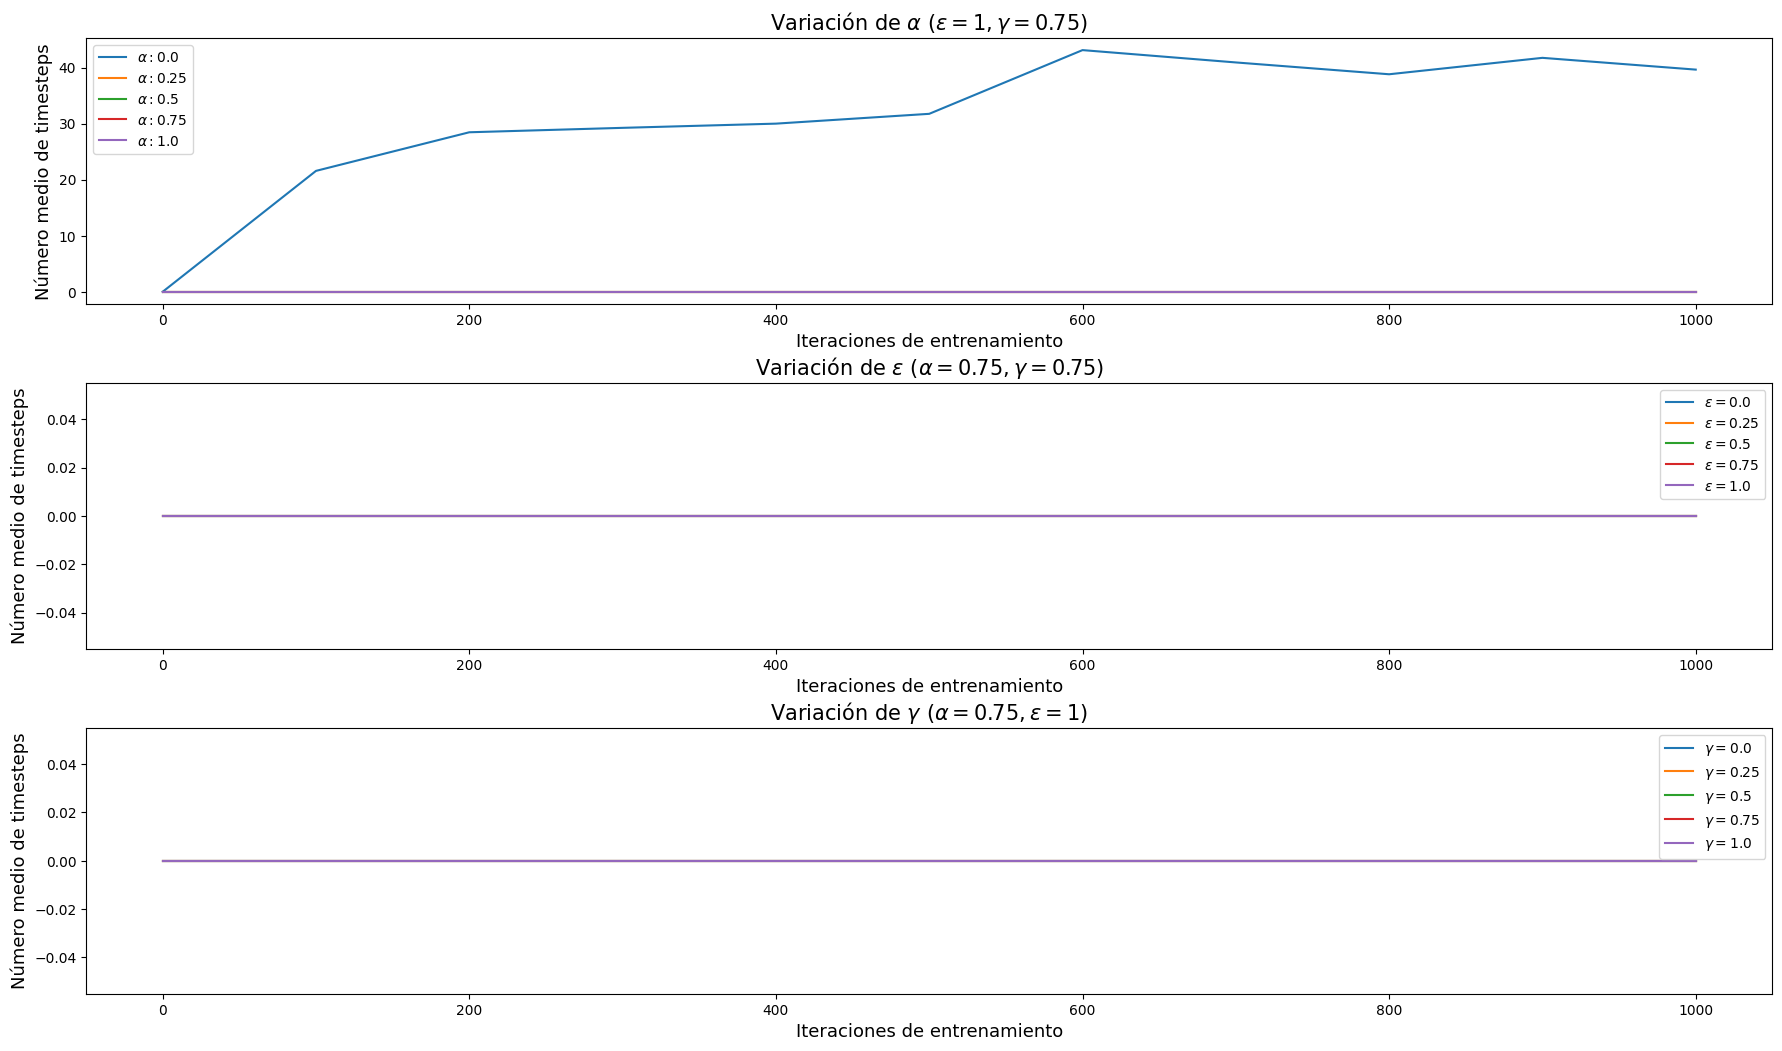

In [13]:
def get_series(alpha, epsilon, gamma):
    alpha_i, epsilon_i, gamma_i = np.digitize(alpha, alphas)-1, np.digitize(epsilon, epsilons)-1,\
        np.digitize(gamma, gammas)-1

    return metric[alpha_i, epsilon_i, gamma_i]



x_axis = np.arange(0, total_episodes, info_control_time)

fig, ax = plt.subplots(3)
fig.tight_layout(pad=0.5)
fig.set_size_inches(18.5, 10.5, forward=True)
#Variacion de alpha
alphas_plots = [alphas, [0.75], [0.75]]
epsilon_plots = [[1], epsilons, [1]]
gammas_plots = [[0.75], [0.75], gammas]

for i in range(0,3):
    current_axis = ax[i]
    for alpha in alphas_plots[i]:
        alpha_i = np.digitize(alpha, alphas)-1
        for epsilon in epsilon_plots[i]:
            epsilon_i = np.digitize(epsilon, epsilons)-1
            for gamma in gammas_plots[i]:
                gamma_i = np.digitize(gamma, gammas)-1
                if i == 0:
                    titulo = f"Variación de $\\alpha \\ (\\epsilon = {{{epsilon}}}, \\gamma={{{gamma}}})$"
                    current_label = f"$\\alpha: {{{alpha}}}$"
                elif i == 1:
                    titulo = f"Variación de $\\epsilon \\ (\\alpha = {{{alpha}}}, \\gamma={{{gamma}}})$"
                    current_label = f"$\\epsilon={{{epsilon}}}$"
                else:
                    titulo = f"Variación de $\\gamma \\ (\\alpha = {{{alpha}}}, \\epsilon={{{epsilon}}})$"
                    current_label = f"$\\gamma={{{gamma}}}$"
                current_axis.plot(x_axis, get_series(alpha, epsilon,gamma), label=current_label)
                current_axis.legend()
                current_axis.set_title(titulo, size = 15)
                current_axis.set_ylabel("Número medio de timesteps", size = 13)
                current_axis.set_xlabel("Iteraciones de entrenamiento", size = 13)
plt.show()


El agente realizado se ha implementado como la clase QLearnAgent. 
El estado del problema tiene 4 valores variables:
- La posición del carro (entre -4.8 y 4.8)
- La velocidad del carro (entre -infinito y +infinito)
- El ángulo que forma el poste respecto al carro (entre -0.418 y 0.418 radianes)
- La velocidad angular del poste (entre -infinito y +infinito)
Todas las variables son continuas y la segunda y la cuarta son no acotadas, con lo que es necesario discretizar el espacio de estados. Para ello, hemos dividido el dominio de cada variable en 20 intervalos. El usuario puede configurar el número de intervalos usados para cada variable mediante el parámetro number_bins. 

El método discretize de la clase QLearnAgent permite determinar en qué intervalo se encuentra cada una de las variables asociadas al estado; de cara al aprendizaje automático todos los valores de un determinado intervalo son idénticos y son tratados de forma homogénea. Aumentar el número de intervalos en los que está dividida cada variable aumenta la precisión del aprendizaje pero también la dimensión del espacio de estados.

Aplicado de esta forma, se puede observar, por ejemplo, que el método de Q-Learning entrenado con 10.000 iteraciones (con hiperparámetros $\alpha = 0.75$, $\gamma = 0.75$, $\epsilon = 1$) el agente conseguía mantener el poste en posición alrededor de 430 *timesteps*, 21 veces más que el comportamiento aleatorio. 

##### Hiperparámetros
Observa en las gráficas el efecto de variar los hiperparámetros en los resultados y en el tiempo de entrenamiento y cual sería la mejor elección de parámetros. 




#### Gráfica de ejemplo que muestra la variación de los hiperparámetros. Genera tus propias gráficas para estudiar el comportamiento y coméntalo.
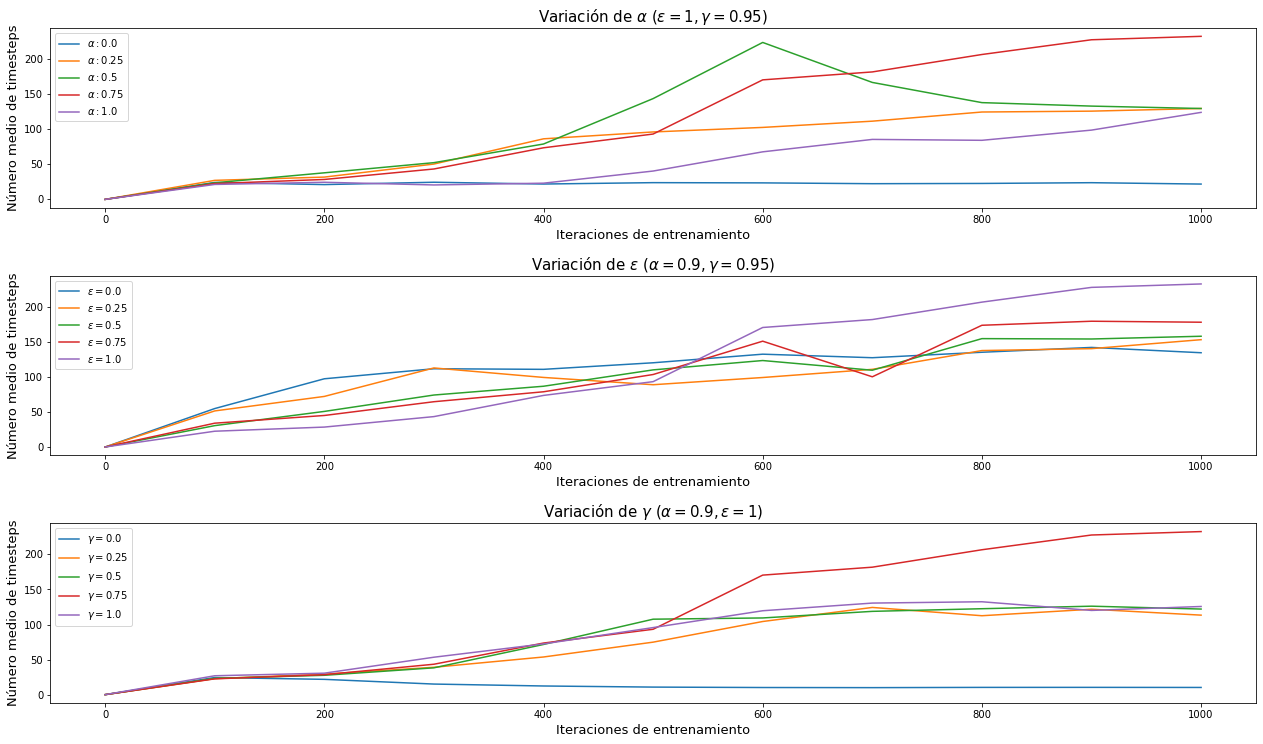

#### Otro ejemplo de gráfico para ver el efecto de la variación de los hiperparámetros
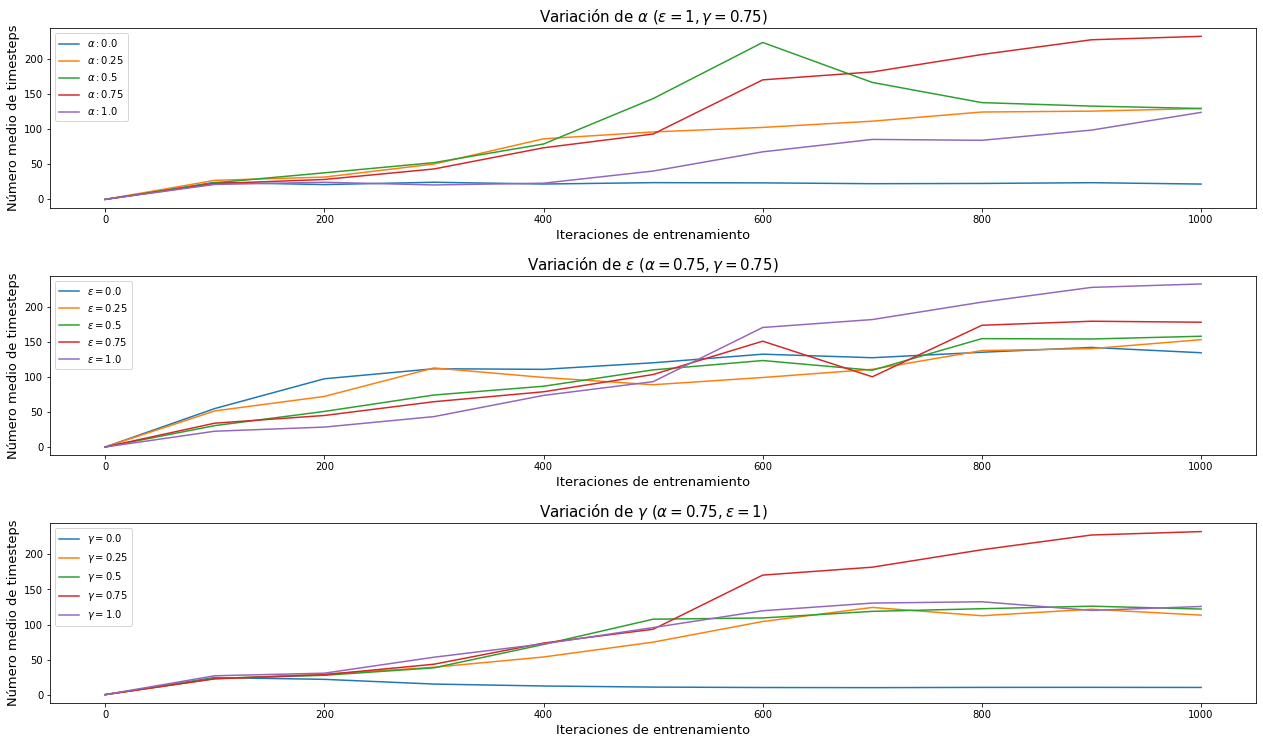

In [14]:
#VARIACIÓN DE ALFA (EPSILON = 1, GAMMA = 0.95)
#En primer lugar, como epsilon = 1 durante todo el entranamiento, estaremos siempre en explotación. Además, como gamma es muy alto
#orientaremos el entrenamiento siempre a dar importancia a las recompensas futuras.
#En relación a la variación de alpha, observamos lo siguiente:
#Cuando alpha = 0.0, tenemos el peor de los casos, el número medio de timesteps es muy bajo. Esto se debe a que otorgamos mucha importancia a la recompensa inmediata,
#y sin embargo, en los primeros episodios lo que merece la pena es dar más importancia a la recompensa futura por el poco conocimiento del agente (preferible orientar al largo plazo qeu al corto plazo), de ahí que se quede anclado en realizar las mismas acciones al 
#principio de cada episodio (el número de timesteps es prácticamente constante) y no supere nunca los 25 timesteps.

#Cuando alpha = 1, tenemos otro caso bastante desventajoso, como mucho se realizan algo más de 100 timesteps. Esto se debe a que este parámetro es ventajoso al principio, porque orientamos el entrenamiento a 
#dar más importancia a la recompensa futura, de ahí que el crecimiento de los timesteps en las primeras iteraciones sea significativo. Sin embargo, una vez hacemos
#aproximadamente la mitad de las iteraciones del entrenamiento, la tasa de crecimiento se reduce, dado que ya no merece tanto la pena otorgar importancia a las recompensas futuras por el 
#alto nivel de conocimiento que ya tiene el agente (ya solo le interesa qué acción tomar en el corto plazo), de hecho, lo ideal sería dar más importancia a las recompensas inmediatas en los últimos episodios.

#Alpha = 0.25, la tasa de crecimiento de los timesteps es bastante regular a medida que pasan las iteraciones. Esto es porque, aunque es un valor que da más importancia a la recompensa inmediata,
#no lo hace tan extremamente como con alpha = 0 y le permite aprender poco a poco en los primeros episodios, aunque lo recomendable fuera un alpha alto. Además, cuando llegamos a los últimos
#episodios estamos en una situación bastante idónea, otorgando bastante importancia a la recompensa inmediata, de ahí que siga creciendo.

#Alpha = 0.5. Caso peculiar, permite aprender al principio porque damos la misma importancia a la recompensa inmediata que a la futura, y a la exploración le vale con eso, luego, los timesteps crecen considerablemente hasta
#la iteración 600, donde alcanza el máximo de timesteps (más de 200), y a partir de donde decrecen significativamente. El porqué de esto es el siguiente: cuando llegamos a la iteración 600, lo recomendable
#es pasar a dar más importancia a la recompensa futura, pero, aunque alpha sea un valor medio entre el corto plazo y el largo plazo, lo cual digamos que fomenta algo el corto plazo, tenemos que gamma es muy alto, que fomenta el largo plazo, 
#creando un conflicto entre los parámetros que no deja decidir al agente qué camino tomar ente corto o largo plazo, de ahí el decrecimiento significativo

#Alpha = 0.75. Este es el mejor de los casos, donde los tiemesteps crecen a lo largo de las iteraciones regularmente. ¿Por qué? Al principio,
#la situación es idónea, porque el alpha está orientado al largo plazo más que al corto plazo. Además, cuando llegamos a los últimos episodios, a diferencia
#del caso anterior, el agente no tiene conflicto con los hiperparámetros, lo que hace que el crecimiento sea más lento, pero siga creciendo.

In [15]:
#VARIACIÓN DE EPSILON (ALPHA = 0.75, GAMMA = 0.75)
#En primer lugar, observamos que los valores de alpha y gamma  fijados orientan el problema al largo plazo, recompensa futura.
#La variación de epsilon nos hace discutir los siguientes casos:

#Los casos epsilon = 0, 0.25 y 0.5 son todos muy similares. En todos ellos (salvo el último que es por igual), orientamos más a la explotación que a la exploración, pero ninguno
# de ellos nos impide aprender al principio, cunado deberíamos oreintar a la epxloración. Eso sí dan lugar a tasas de crecimiento mayores cuanto mayor es el epsilon (a lo largo de todas las iteraciones).
#Eso sí, en todos los casos, digamos que el crecimiento no es mayor al fina, donde estos valores de epsilon serían idóneos, porque el agente no ha aprendido lo suficiente al principio (no 
#aprovechamos la explotación).

#Epsilon = 0.75, es, de los estudiados hasta ahora, el que más timesteps alcanza, y esto es porque aprovecha muy bien al principio la etapa de exploración ayudado por los hiperparámetros, y aunque el valor en los
#últimos episodios no sea el idóneo, y se produzcan fluctuaciones en los timesteps realizados, caba alcanzando más de 150, lo cual demuestra que ha aprendido mejor.
#Es decir, a pesar de no tener el valor adecuado al final, aprovecha mucho la etapa de exploracaión al principio para aumentar los tiemesteps.

#Finalmente, el mejor valor es epsilon = 1, por el mismo motivo que antes, aprovecha mucho, de hecho, más que en el caso anterior, la exploración ayudado por los hiperparámetros haciendo crecer mucho los timesteps

In [16]:
#VARIACIÓN DE GAMMA (ALPHA = 0.9, EPSILON = 1)
#En primer lugar, el valor de alpha hace que se oriente al corto plazo, y el de epsilon a la exploración, están orientados a los primeros episodios.
#Gamma = 0, peor de los casos, el agente no puede aprender al principio porque este valor de gamma solo fomenta el corto plazo, descartando el largo plazo, de ahí que se quede atascado.
#Gamma = 0.25, 0.5 o 1, muy similares los tres. Los dos primeros fomentan mucho el corto plazo, pero sin descartar el largo plazo, de ahí que al principio 
#los timesteps crezcan pero con un ritmo lento. Al final, al orientar al corto plazo, que es lo idóneo, el crecimiento es más rápido, pero no se puede aprovechar mucho porque el agente no ha
#adquirido el conocimiento suficiente. Cuando gamma = 1, se le otorga solo importancia. En los tres casos no se superan los 150 timesteps.
#al largo plazo, permitiendo crecer a un buen ritmo al principio a los timesteps, pero quedánodse prácticamente constante en los últimos episodios.
#Gamma = 0.75, valor idóneo. Permite dar bastante importancia al largo plazo en los primeros episodios, lo que da lugar a un crecimiento significativo, y al final
#no impide del todo el corto plazo, con lo que, añadido a que el agente ha adquirido bastante conocimiento, sigue creciendo aunque no a un ritmo tan alto, llegando a más de 200 timesteps.

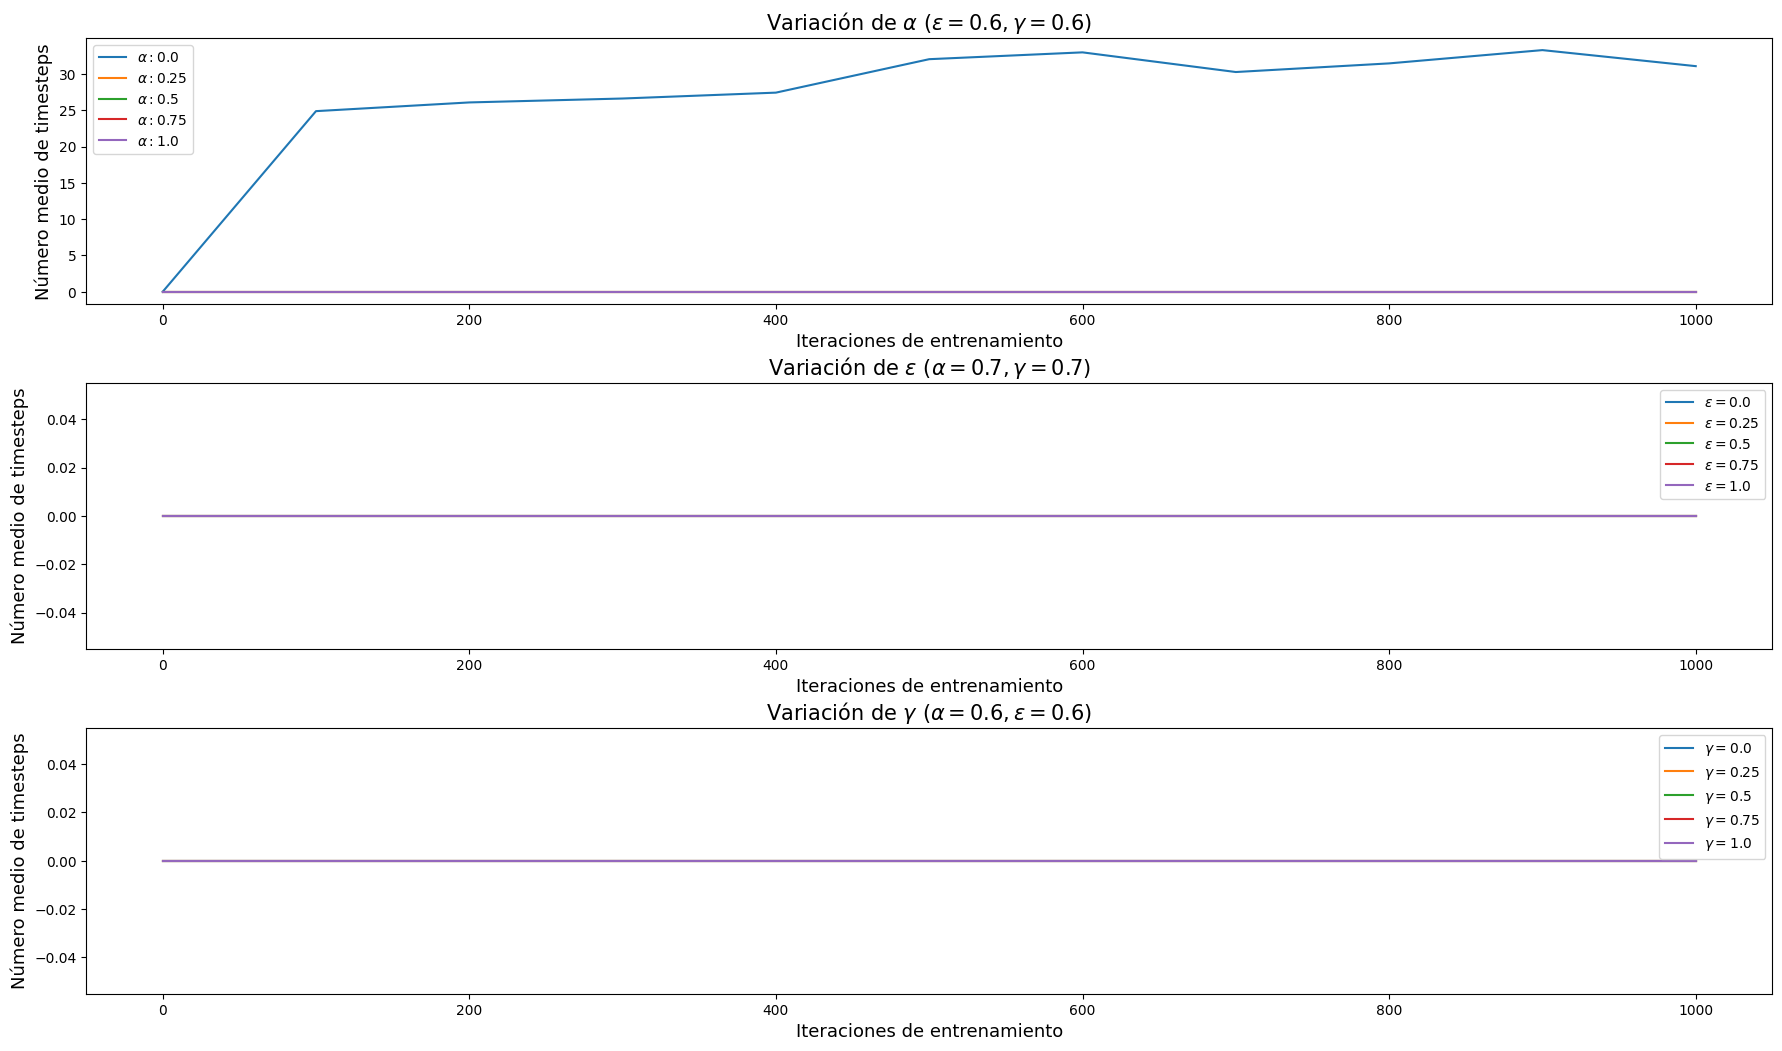

In [22]:
alphas, epsilons, gammas = np.linspace(0, 1, 5), np.linspace(0,1,5),\
    np.linspace(0,1, 5)


def get_series(alpha, epsilon, gamma):
    alpha_i, epsilon_i, gamma_i = np.digitize(alpha, alphas)-1, np.digitize(epsilon, epsilons)-1,\
        np.digitize(gamma, gammas)-1

    return metric[alpha_i, epsilon_i, gamma_i]



x_axis = np.arange(0, total_episodes, info_control_time)

fig, ax = plt.subplots(3)
fig.tight_layout(pad=0.5)
fig.set_size_inches(18.5, 10.5, forward=True)
#Variacion de alpha
alphas_plots = [alphas, [0.7], [0.6]]
epsilon_plots = [[0.6], epsilons, [0.6]]
gammas_plots = [[0.6], [0.7], gammas]

for i in range(0,3):
    current_axis = ax[i]
    for alpha in alphas_plots[i]:
        alpha_i = np.digitize(alpha, alphas)-1
        for epsilon in epsilon_plots[i]:
            epsilon_i = np.digitize(epsilon, epsilons)-1
            for gamma in gammas_plots[i]:
                gamma_i = np.digitize(gamma, gammas)-1
                if i == 0:
                    titulo = f"Variación de $\\alpha \\ (\\epsilon = {{{epsilon}}}, \\gamma={{{gamma}}})$"
                    current_label = f"$\\alpha: {{{alpha}}}$"
                elif i == 1:
                    titulo = f"Variación de $\\epsilon \\ (\\alpha = {{{alpha}}}, \\gamma={{{gamma}}})$"
                    current_label = f"$\\epsilon={{{epsilon}}}$"
                else:
                    titulo = f"Variación de $\\gamma \\ (\\alpha = {{{alpha}}}, \\epsilon={{{epsilon}}})$"
                    current_label = f"$\\gamma={{{gamma}}}$"
                current_axis.plot(x_axis, get_series(alpha,epsilon,gamma), label=current_label)
                current_axis.legend()
                current_axis.set_title(titulo, size = 15)
                current_axis.set_ylabel("Número medio de timesteps", size = 13)
                current_axis.set_xlabel("Iteraciones de entrenamiento", size = 13)
plt.show()


In [23]:
#Estas gráficas son ejemplos aportados por nosotros difiriendo en los valores iniciales de los parámetros que no varían (reducimos todos un poco):

In [20]:
#Variación de alpha: la dinámica es muy similar a la del ejemplo comentado anteriormente. En este caso, el mejor caso vuelve a ser alpha = 0.5.

In [ ]:
#Variación de epsilon: Salvo el epsilon = 0, el resto de valores se comportan de manera muy similar, llevando a cabo un crecimiento regular de los timesteps, hasta llegar a cerca de los 140..
#Sin embargo, es llamativo el caso de epsilon = 1, donde el agente no puede aprender, se queda constante en 0 timesteops en todos los episodios. Esto se puede deber a que
#la configuración del resto de los parámetros para poder aprender requieren, algo, aunque sea mínimo, de explotación, y con este valor de epsilon estamos constantemente en exploración
#omitiendo completamente la posibilidad de explotación.

In [ ]:
#Variación de gamma: dinámica muy similar a la del ejemplo comentado anteiormente, solo que enste caso, los timesteps máximos se alcanzan
#con gamma = 1, aunque al final decrezca un poco debido a su orientación extrema hacia el largo plazo. Salvo el gamma = 0, que sigue siendo el peor caso,
#los otros valores de gamma tienen comportamientos muy similares, siendo algo mejor que el resto gamma = 0.5, donde los timesteps crecen regularmente, por dar
#importancia similar al corto y al largo plazo.

In [ ]:

#Finalmente, cabe destacar que con estos parámetros utilizados nunca se llega a valores tan altos de timesteps como en los ejemplos anteriores,
#donde teníamos hasta 200 timesteps, ya que en estos ejemplos como mucho se alcanzan los 160 timesteps. De aquí podemos concluir que es mejor fijar parámetros altos que bajos,
#es decir, tener una buena configuración de parámetros en los primeros episodios (valores altos de todos los hiperparámetros) a cambio de que al final esta configuración no sea tan buena.

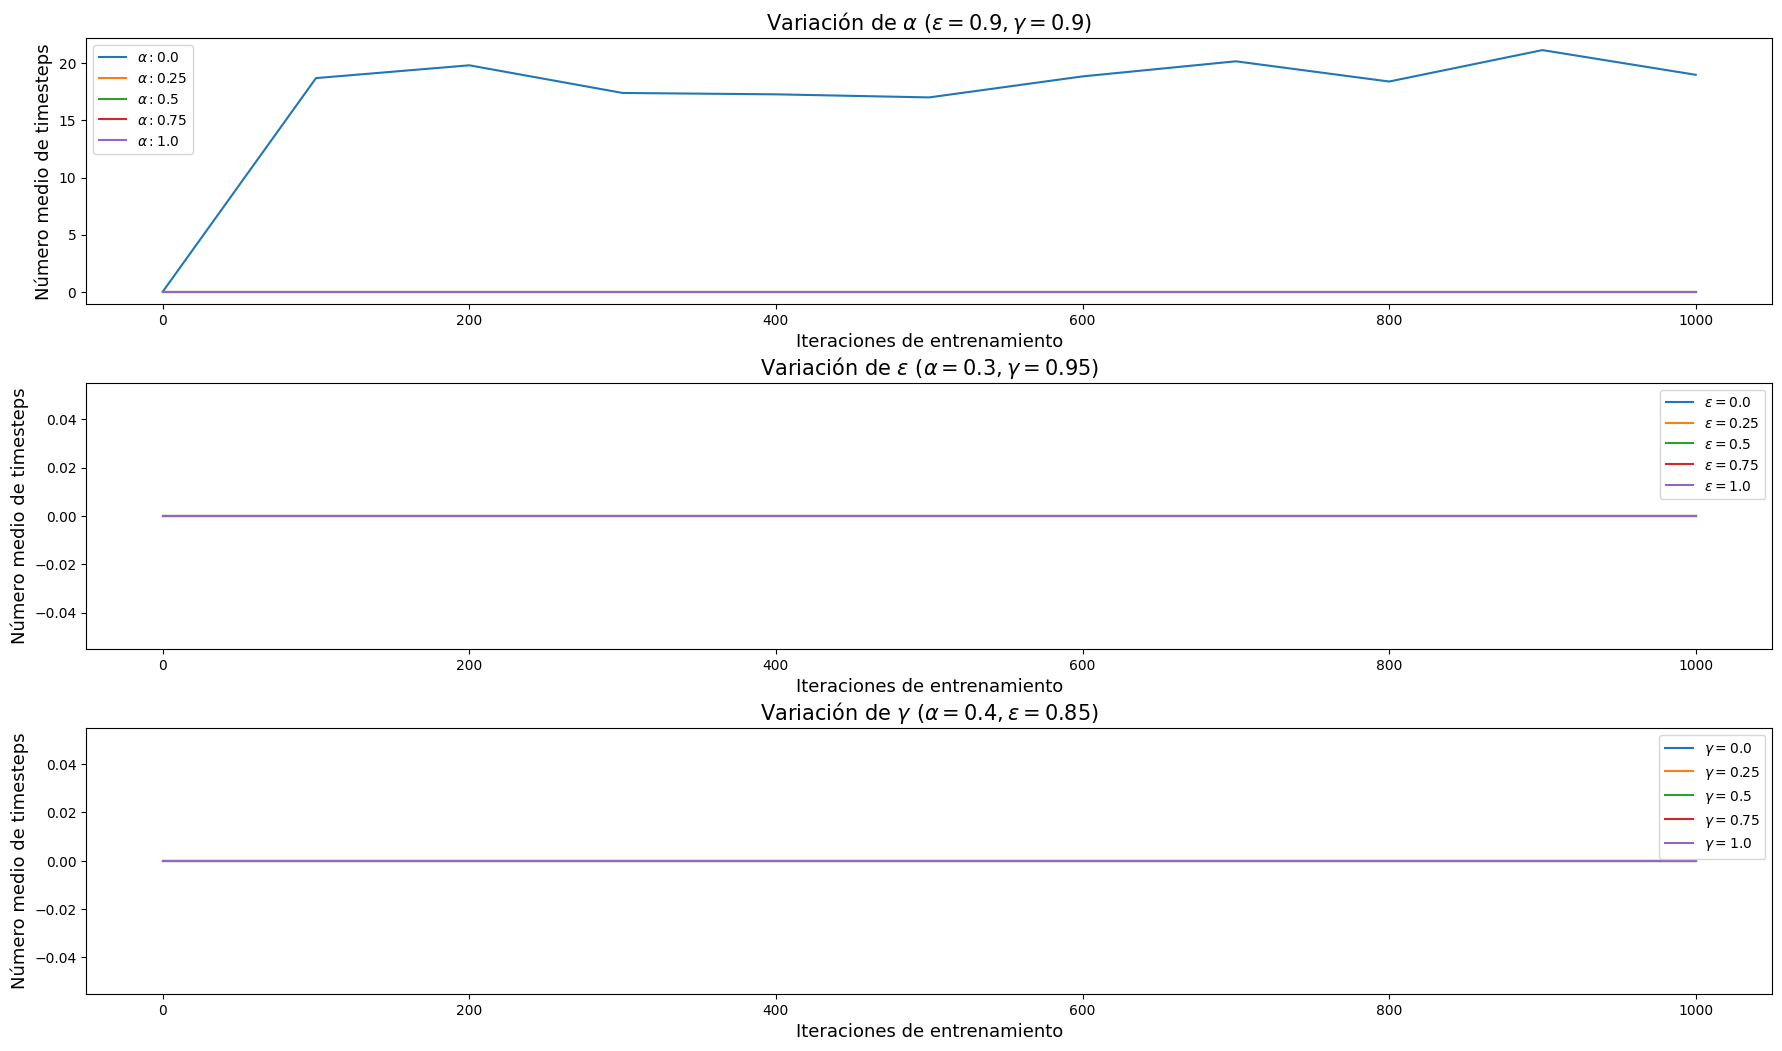

In [21]:
alphas, epsilons, gammas = np.linspace(0, 1, 5), np.linspace(0,1,5),\
    np.linspace(0,1, 5)


def get_series(alpha, epsilon, gamma):
    alpha_i, epsilon_i, gamma_i = np.digitize(alpha, alphas)-1, np.digitize(epsilon, epsilons)-1,\
        np.digitize(gamma, gammas)-1

    return metric[alpha_i, epsilon_i, gamma_i]



x_axis = np.arange(0, total_episodes, info_control_time)

fig, ax = plt.subplots(3)
fig.tight_layout(pad=0.5)
fig.set_size_inches(18.5, 10.5, forward=True)
#Variacion de alpha
alphas_plots = [alphas, [0.3], [0.4]]
epsilon_plots = [[0.9], epsilons, [0.85]]
gammas_plots = [[0.9], [0.95], gammas]

for i in range(0,3):
    current_axis = ax[i]
    for alpha in alphas_plots[i]:
        alpha_i = np.digitize(alpha, alphas)-1
        for epsilon in epsilon_plots[i]:
            epsilon_i = np.digitize(epsilon, epsilons)-1
            for gamma in gammas_plots[i]:
                gamma_i = np.digitize(gamma, gammas)-1
                if i == 0:
                    titulo = f"Variación de $\\alpha \\ (\\epsilon = {{{epsilon}}}, \\gamma={{{gamma}}})$"
                    current_label = f"$\\alpha: {{{alpha}}}$"
                elif i == 1:
                    titulo = f"Variación de $\\epsilon \\ (\\alpha = {{{alpha}}}, \\gamma={{{gamma}}})$"
                    current_label = f"$\\epsilon={{{epsilon}}}$"
                else:
                    titulo = f"Variación de $\\gamma \\ (\\alpha = {{{alpha}}}, \\epsilon={{{epsilon}}})$"
                    current_label = f"$\\gamma={{{gamma}}}$"
                current_axis.plot(x_axis, get_series(alpha,epsilon,gamma), label=current_label)
                current_axis.legend()
                current_axis.set_title(titulo, size = 15)
                current_axis.set_ylabel("Número medio de timesteps", size = 13)
                current_axis.set_xlabel("Iteraciones de entrenamiento", size = 13)
plt.show()
